In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../src')
from parallel_utils import jax_joblib_configuration
jax_joblib_configuration()

from functools import partial
from pathlib import Path
import numpy as np
import polars as pl
from matplotlib import pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib as mpl
from matplotlib.ticker import AutoMinorLocator
from matplotlib_config import rcparams
mpl.rcParams.update(rcparams)

import jax
from jax import random
from jax import numpy as jnp
from tinygp import GaussianProcess, kernels
from corner import corner
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from numpyro.infer.initialization import init_to_median
numpyro.set_host_device_count(4)

from vi import fit_vi, sample_posterior_laplace
from robust_periodicity import clean_light_curve, unpack_light_curve
from robust_periodicity import bayesian_red_noise, build_gp, _build_gp, fit_gp_red_noise, build_gp,  sample_gp_prior
from robust_periodicity import compute_periodogram, top_peaks_over_bins, compute_frequency_grid, batched_p_value_max_periodogram

path_dataset = Path('../data/gaia_qso_initial_selection_40obs_500d/')

fbin = 0 
significance = 1e-3

/home/pabloh/work/GASP/.venv/lib/python3.12/site-packages/astropy/config/paths.py:55: AstropyUserWarning: XDG_CONFIG_HOME is set to '/home/pabloh/.config', but the default location, /home/pabloh/.astropy/config, already exists, and takes precedence. This environment variable will be ignored.
  return set_temp_config._get_dir_path(rootname)


# Running the pipeline interactively on a single source

## Preprocessing

This mainly consists of removing observations flag by Gaia CU7 and outliers

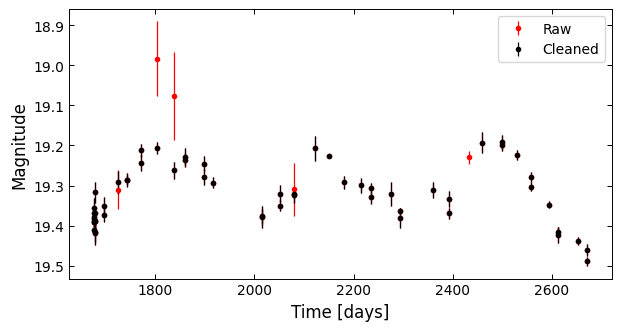

In [2]:
# Select a source ID within the sample
sid = 4739629868656108160 
#sid = 4933441058163143808
#sid = 805278300393299584
#sid = 1543792150205554688

df_lc = pl.scan_parquet(path_dataset / 'part_*.parquet').filter(pl.col('sourceid').eq(sid)).collect()
lc_raw = unpack_light_curve(df_lc, apply_variability_reject_mask=False)
time_raw, mag_raw, err_raw = lc_raw['g']
lc = clean_light_curve(unpack_light_curve(df_lc, apply_variability_reject_mask=True), remove_extreme_errors=True, remove_extreme_values=True, extreme_value_threshold=1.5, extreme_error_threshold=3)
time, mag, err = lc['g']

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.errorbar(time_raw, mag_raw, err_raw, fmt='.', c='r', label='Raw')
ax.errorbar(time, mag, err, fmt='.', c='k', label='Cleaned')
ax.invert_yaxis()
ax.set_xlabel('Time [days]')
ax.set_ylabel('Magnitude')
ax.legend()

time_jax, mag_jax, err_jax = jnp.asarray(time), jnp.asarray(mag), jnp.asarray(err)
time_interp = jnp.linspace(jnp.amin(time), jnp.amax(time), 500)

## Red noise modelling

Next, we fit a red noise model based on Gaussian processes to the preprocessed time series. A (relatively cheap) Maximum a Posteriori (MAP) fit with Laplace-approximation uncertanties is used.

The plots show the evolution of the cost/loss function and the resulting fit

Text(0, 0.5, 'Magnitude')

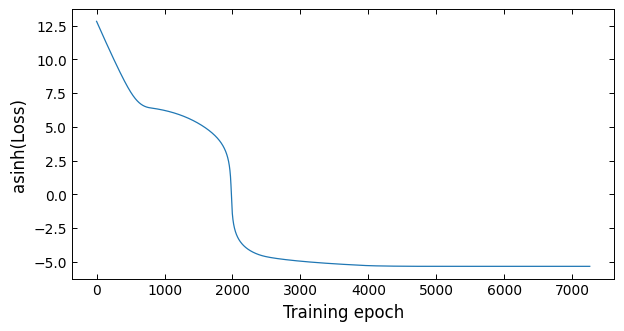

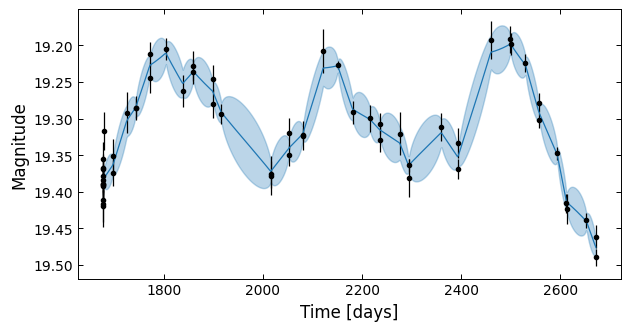

In [3]:
subkey = random.PRNGKey(1234)
model = partial(bayesian_red_noise, fit_gamma=False)
guide, vi_params, losses = fit_vi(
    model, subkey, x=time_jax, yerr=err_jax, y=mag_jax, guide_type='Laplace', lr=5e-3, max_steps=10_000, num_particles=1, early_stopping=True
)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(np.asinh(losses))
ax.set_xlabel('Training epoch')
ax.set_ylabel('asinh(Loss)') # asinh is used instead of log to compress the scale because the loss can be negative

gp = build_gp({'mean': vi_params['auto_loc'][0], 'log_sigma': vi_params['auto_loc'][1], 'log_tau': vi_params['auto_loc'][2]}, X=time_jax, Yerr=err_jax)
_, cond = gp.condition(mag_jax, time_interp, include_mean=True)
mu, std = cond.loc, jnp.sqrt(cond.variance)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.errorbar(time, mag, err, fmt='.', c='k')
ax.plot(time_interp, mu, label="GP model", color="C0")
ax.fill_between(time_interp, mu + std, mu - std, color="C0", alpha=0.3)
ax.invert_yaxis()
ax.set_xlabel('Time [days]')
ax.set_ylabel('Magnitude')

Now we can sample from the posterior. The plot below shows the samples in the parameter space and in time series space (only three shown). 

Text(0, 0.5, 'Magnitude')

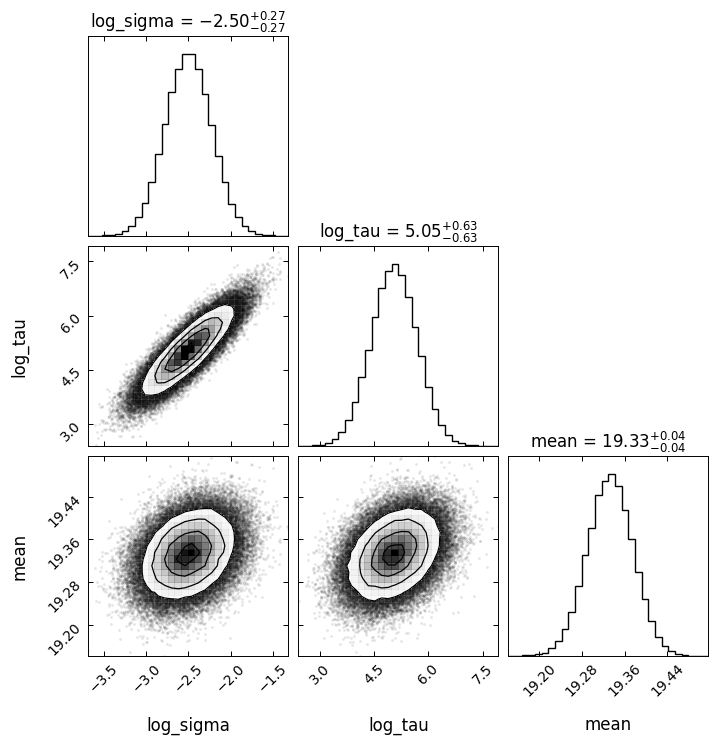

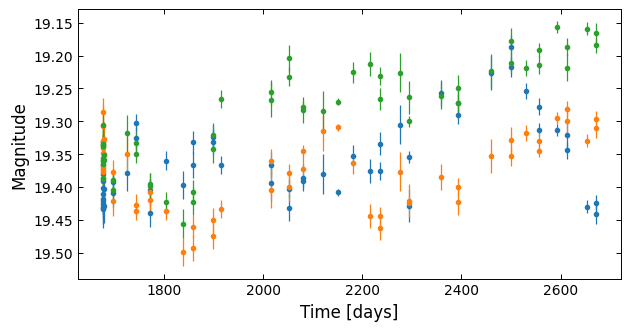

In [4]:
subkey = random.PRNGKey(1234)
samples = sample_posterior_laplace(
    model, subkey, vi_params, x=time_jax, yerr=err_jax, y=mag_jax, num_samples=100_000
)

corner(
    data=np.stack([v for k, v in samples.items() if 'pred' not in k]).T, 
    bins=30, labels=[k for k in samples.keys() if 'pred' not in k], show_titles=True, 
);

keys = random.split(subkey, len(samples['log_sigma']))
gp_prior_samples = jax.jit(jax.vmap(partial(sample_gp_prior, time=time, err=err)))(**samples, key=keys)[:, 0, :]

fig, ax = plt.subplots(figsize=(7, 3.5))
for y_sample in gp_prior_samples[:3]:
    ax.errorbar(time, y_sample, err, fmt='.')
ax.invert_yaxis()
ax.set_xlabel('Time [days]')
ax.set_ylabel('Magnitude')

## Frequency analysis and FAP estimation

First we compute the Lomb-Scargle periodogram of the original data. The Baluev false alarm probability (FAP) of the dominant peak is shown for reference

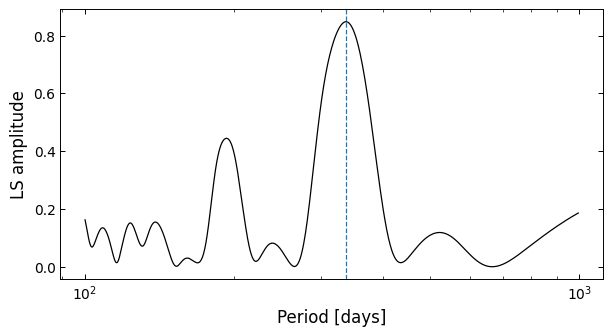

In [5]:
T = time[-1] - time[0]
samples_per_peak = 100
fmin, fmax, fres = 1/T, 0.01, (1/T) / samples_per_peak

freqs = compute_frequency_grid(fmin, fmax, fres)
ampls = compute_periodogram(time, mag, err, fmin, fmax, fres)
periodogram_peaks = top_peaks_over_bins(time, mag, err, freqs, ampls, samples_per_peak)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(1/freqs, ampls, c='k')
ax.axvline(1/periodogram_peaks['top_frequency'][fbin], ls='--')
ax.set_xscale('log')
ax.set_xlabel('Period [days]')
ax.set_ylabel('LS amplitude');

The dominant peak is significant if we follow the Baleuv FAP prescription. However, this is not appropriate when we deal with red noise.

In [6]:
periodogram_peaks['top_fap'][fbin], periodogram_peaks['top_fap'][fbin] < significance

(1.1718177427232505e-20, True)

Using the 100,000 realizations we obtain the distribution of maximum LS peak under our null hypothesis of red noise

The following takes 1m of compute and shows such distribution with the observed amplitude as a dashed line

CPU times: user 33.8 s, sys: 458 ms, total: 34.3 s
Wall time: 32.9 s


Text(0.5, 0, 'LS amplitude')

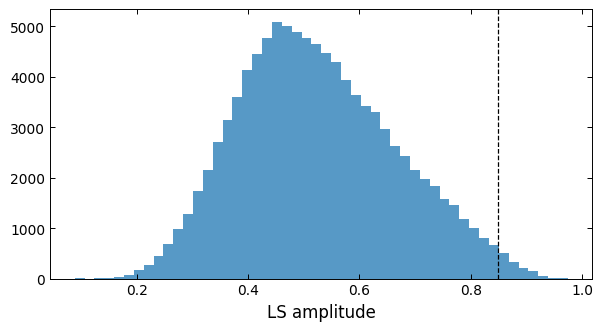

In [7]:
%%time

ampls_distro = np.array([np.amax(compute_periodogram(time, y_sample, err, fmin, fmax, fres, normalization='standard')) for y_sample in gp_prior_samples])

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(ampls_distro, bins=50, alpha=0.75)
ax.axvline(periodogram_peaks['top_amplitude'][fbin], ls='--', c='k')
ax.set_xlabel('LS amplitude')

Note that if we only want the p-value the following function is more convenient and faster (few seconds):

In [8]:
%%time

from robust_periodicity import batched_p_value_max_periodogram 

row = pl.DataFrame([periodogram_peaks])
p_value = batched_p_value_max_periodogram(
    row['top_amplitude'][0].to_numpy(), np.stack([row['bin_freq_lo'][0].to_numpy(), row['bin_freq_hi'][0].to_numpy()]).T, time, gp_prior_samples, err, fres, batch_size=100)[0]
p_value[fbin], p_value[fbin] < significance

CPU times: user 4.64 s, sys: 249 ms, total: 4.89 s
Wall time: 4.89 s


(np.float64(0.013504864951350486), np.False_)

> The peak we have observed is not significant under red-noise

All in one figure for the paper:

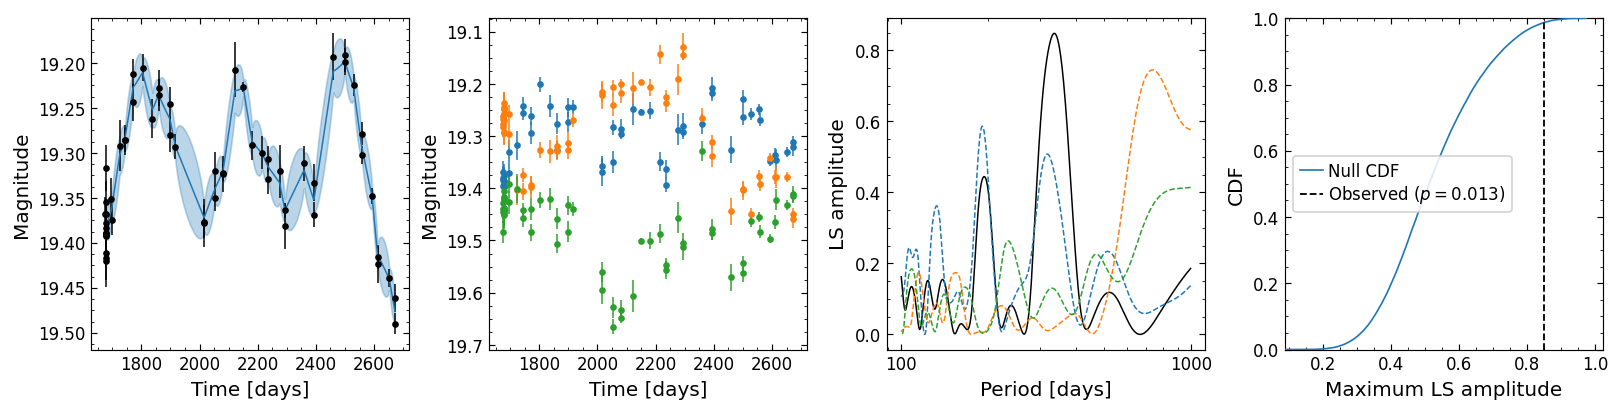

In [9]:
fig = plt.figure(figsize=(14, 4), dpi=120)
gs  = gridspec.GridSpec(1, 4, figure=fig, left=0.07, right=0.97, bottom=0.20, top=0.89, wspace=0.25)
ax1, ax2, ax3, ax4 = [fig.add_subplot(gs[i]) for i in range(4)]
ax1.errorbar(time, mag, err, fmt='.', c='k')
ax1.plot(time_interp, mu, label="GP model", color="C0")
ax1.fill_between(time_interp, mu + std, mu - std, color="C0", alpha=0.3)
ax1.invert_yaxis()
ax1.xaxis.set_minor_locator(AutoMinorLocator(4))
ax1.yaxis.set_minor_locator(AutoMinorLocator(4))
ax1.set_xlabel('Time [days]')
ax1.set_ylabel('Magnitude')

ax2.invert_yaxis()
for y_sample in gp_prior_samples[-3:]:
    ax2.errorbar(time, y_sample, err, fmt='.')
ax2.xaxis.set_minor_locator(AutoMinorLocator(4))
ax2.yaxis.set_minor_locator(AutoMinorLocator(4))
ax2.set_xlabel('Time [days]')
ax2.set_ylabel('Magnitude')

ampls = compute_periodogram(time, mag, err, fmin, fmax, fres, normalization='standard')
ax3.plot(1/freqs, ampls, c='k')
for y_sample in gp_prior_samples[-3:]:
    ampls_ = compute_periodogram(time, y_sample, err, fmin, fmax, fres, normalization='standard')
    ax3.plot(1/freqs, ampls_, ls='--')
ax3.set_xscale('log')
ax3.set_xlabel('Period [days]')
ax3.set_ylabel('LS amplitude')
#ax3.xaxis.set_minor_locator(mpl.ticker.LogLocator(subs='all', numticks=4))
ax3.yaxis.set_minor_locator(AutoMinorLocator(4))
ax3.xaxis.set_major_formatter(mpl.ticker.ScalarFormatter())
ax3.xaxis.set_minor_formatter(mpl.ticker.NullFormatter())
ax3.ticklabel_format(axis='x', style='plain')
ax4.set_xlabel('Maximum amplitude')


p_val  = np.mean(ampls_distro >= np.amax(ampls))
x_sort = np.sort(ampls_distro)
cdf    = np.arange(1, len(x_sort) + 1) / len(x_sort)

ax4.plot(x_sort, cdf, color='C0', lw=1.0, zorder=3, label='Null CDF')
ax4.axvline(np.amax(ampls), color='k', lw=1.1, ls='--', zorder=5,
            label=fr'Observed ($p={p_val:.3f}$)')
ax4.set_xlabel(r'Maximum LS amplitude')
ax4.set_ylabel(r'CDF')
ax4.xaxis.set_minor_locator(AutoMinorLocator(4))
ax4.yaxis.set_minor_locator(AutoMinorLocator(4))
ax4.set_ylim(0, 1)
ax4.set_xlim(x_sort[0], x_sort[-1] * 1.05)
ax4.legend(loc='center left', handlelength=1.4, framealpha=0.85,
           borderpad=0.4, labelspacing=0.2, handletextpad=0.3)
fig.savefig('figures/methodology.pdf', bbox_inches='tight', dpi=300)

## FAP estimation using MCMC and a powered exponential kernel

Four sources that pass the significance threshold we redo the analysis using MCMC instead of MAP to obtain a more reliable posterior. 

We also test kernels beyond DRW (exponential) like the power exponential (additional parameter `gamma`)

In [10]:
%%time

nuts_kernel = NUTS(partial(bayesian_red_noise, fit_gamma=True), target_accept_prob=0.9, dense_mass=True, max_tree_depth=(5, 10))
mcmc = MCMC(nuts_kernel, num_warmup=500, num_samples=5000, num_chains=4, progress_bar=True, jit_model_args=True, chain_method='vectorized')

rng_key = random.PRNGKey(55873)
mcmc.run(rng_key, x=time, y=mag, yerr=err, x_interp=time_interp)
samples = mcmc.get_samples()
print(mcmc.print_summary())

sample: 100%|█████████████████████████████████████████████████████████████████████████████████████| 5500/5500 [01:17<00:00, 70.68it/s]



                   mean       std    median      5.0%     95.0%     n_eff     r_hat
    log_sigma     -2.19      0.41     -2.26     -2.80     -1.59   3320.92      1.00
      log_tau      5.04      0.53      4.96      4.27      5.88   3748.19      1.00
  logit_gamma      0.26      0.76      0.29     -0.95      1.51   9825.36      1.00
         mean     19.35      0.10     19.33     19.24     19.46   1715.72      1.00

Number of divergences: 0
None
CPU times: user 1min 41s, sys: 2.47 s, total: 1min 43s
Wall time: 1min 23s


No divergences and Gelman-Rubin statistic close to one for all parameters. The sampled posterior:

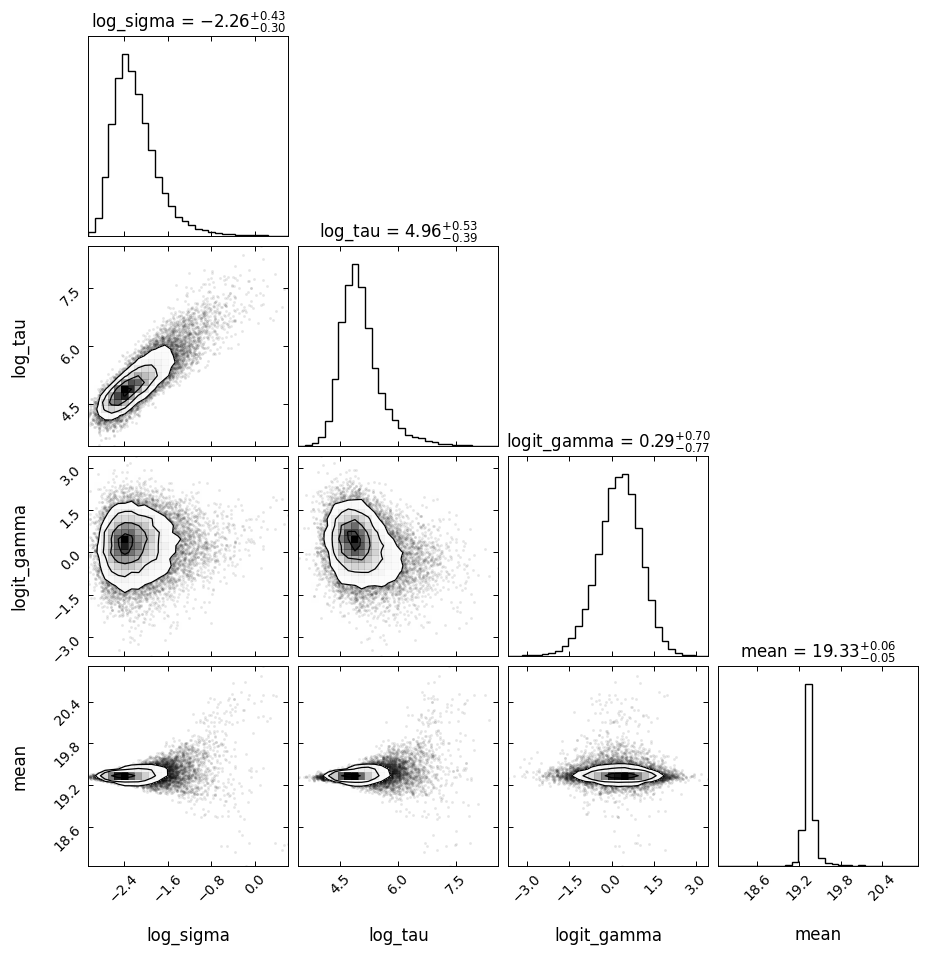

In [11]:
corner(
    data=np.stack([v for k, v in samples.items() if 'pred' not in k]).T, 
    bins=30, labels=[k for k in samples.keys() if 'pred' not in k], show_titles=True, 
);

The following creates the GP realizations out of the parameter posterior and computes the MCMC-based p-value

In [12]:
def sample_gp_prior(log_sigma, log_tau, mean, key, logit_gamma=None, num_samples=1, kernel_fn=None):
    return _build_gp(X=time, Yerr=err, log_sigma=log_sigma, log_tau=log_tau, mean=mean, kernel_fn=kernel_fn, logit_gamma=logit_gamma).sample(key, shape=(num_samples, ))

key0 = random.PRNGKey(1234)
keys = random.split(key0, len(samples['log_sigma']))
gp_prior_samples_mcmc = jax.jit(jax.vmap(sample_gp_prior))(**{k: v for k, v in samples.items() if 'pred' not in k}, key=keys)[:, 0, :]

p_value = batched_p_value_max_periodogram(
    row['top_amplitude'][0].to_numpy(), np.stack([row['bin_freq_lo'][0].to_numpy(), row['bin_freq_hi'][0].to_numpy()]).T, 
    time, gp_prior_samples_mcmc, err, fres, batch_size=100
)[0]
p_value[fbin], p_value[fbin] < significance

(np.float64(0.06932153392330384), np.False_)

Still insignificant, but the FAP is a bit higher than the MAP case